# 한국어 단어 임베딩의 젠더 편향 측정 및 분석

> **Korean Word Embedding Gender Bias Measurement via WEAT**  
> Caliskan et al. (2017) + Bolukbasi et al. (2016) hard debiasing

---

**분석 흐름:**
1. 임베딩 모델 로드 (FastText / Word2Vec)
2. 어휘 커버리지 확인
3. WEAT 측정 (debiasing 전)
4. 시각화: bar chart, PCA scatter, cosine heatmap
5. Hard debiasing 적용
6. WEAT 재측정 (debiasing 후)
7. 전후 비교 시각화
8. 결과 저장

## 0. 설정 및 임포트

In [1]:
import sys
from pathlib import Path

# Add project root to path
ROOT = Path("..")
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.word_sets import get_korean_word_sets, CATEGORY_LABELS, WEAT_TESTS
from src.load_embeddings import (
    load_fasttext_korean,
    load_word2vec_namuwiki,
    verify_model_words,
    print_coverage_report,
    ModelNotFoundError,
)
from src.weat import run_all_occupation_tests, WEATResult
from src.debiasing import build_debiased_lookup
from src.visualize import (
    plot_weat_bar_chart,
    plot_pca_scatter,
    plot_cosine_heatmap,
    plot_debiasing_comparison,
    save_results_csv,
    results_to_dataframe,
)

# Paths
FASTTEXT_PATH = ROOT / "models" / "cc.ko.300.bin"
WORD2VEC_PATH = ROOT / "models" / "ko.bin"  # adjust if using a different filename
FIGURES_DIR   = ROOT / "results" / "figures"
CSV_DIR       = ROOT / "results" / "csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

N_PERMUTATIONS = 10_000

print("Setup complete.")

Setup complete.


## 1. 임베딩 모델 로드

In [2]:
# --- FastText (primary) ---
# First load writes ~4 GB mmap files alongside cc.ko.300.bin; takes ~3-5 min.
# Subsequent loads are near-instant.
ft_model = load_fasttext_korean(FASTTEXT_PATH)
print(f"FastText loaded: dim={ft_model.dim}")

Loading FastText model from ../models/cc.ko.300.bin (this may take a few minutes on first load)...
FastText loaded: dim=300


In [3]:
# --- Word2Vec (cross-validation; skip gracefully if unavailable) ---
w2v_model = None
try:
    w2v_model = load_word2vec_namuwiki(WORD2VEC_PATH)
    print(f"Word2Vec loaded: dim={w2v_model.dim}")
except ModelNotFoundError as e:
    print(f"[INFO] Word2Vec not available — skipping cross-validation.\n{e}")

Loading Word2Vec model from ../models/ko.bin...
Word2Vec loaded: dim=200


## 2. 어휘 커버리지 확인

WEAT 단어들이 모델 어휘에 존재하는지 확인한다.  
각 집합에서 5개 미만이면 해당 테스트가 건너뛰어진다.

In [4]:
word_sets = get_korean_word_sets()

ft_report = verify_model_words(ft_model, word_sets)
print_coverage_report(ft_report, model_name="FastText cc.ko.300")

# Polysemy notes
print("\n[주의] 다의어 주의:")
print("  '그': 대명사(he)이지만 지시사(that)로도 매우 자주 사용됨 → 벡터가 지시사 의미에 편향될 수 있음")
print("  '의사': 醫師(doctor), 意思(intent), 義士(martyr) 세 가지 의미가 하나의 벡터에 혼합됨")


Coverage report — FastText cc.ko.300
--------------------------------------------------
  [OK] male_attrs: 8/8 (100.0%)
  [OK] female_attrs: 8/8 (100.0%)
  [OK] male_occupations: 7/7 (100.0%)
  [OK] female_occupations: 5/5 (100.0%)
  [OK] neutral_occupations: 5/5 (100.0%)


[주의] 다의어 주의:
  '그': 대명사(he)이지만 지시사(that)로도 매우 자주 사용됨 → 벡터가 지시사 의미에 편향될 수 있음
  '의사': 醫師(doctor), 意思(intent), 義士(martyr) 세 가지 의미가 하나의 벡터에 혼합됨


In [5]:
if w2v_model:
    w2v_report = verify_model_words(w2v_model, word_sets)
    print_coverage_report(w2v_report, model_name="Word2Vec (Namuwiki)")


Coverage report — Word2Vec (Namuwiki)
--------------------------------------------------
  [OK] male_attrs: 8/8 (100.0%)
  [OK] female_attrs: 8/8 (100.0%)
  [OK] male_occupations: 7/7 (100.0%)
  [OK] female_occupations: 5/5 (100.0%)
  [OK] neutral_occupations: 5/5 (100.0%)



## 3. WEAT 측정 — Debiasing 전

세 가지 테스트:  
1. 전통 남성 직종 vs 전통 여성 직종  
2. 중립/전문직 vs 전통 남성 직종  
3. 중립/전문직 vs 전통 여성 직종

$d > 0$: X집합이 남성(A)에 더 연관됨  
$d < 0$: X집합이 여성(B)에 더 연관됨

In [6]:
ft_results_before = run_all_occupation_tests(
    ft_model, word_sets, n_permutations=N_PERMUTATIONS
)

print("FastText — WEAT Results (before debiasing)")
print("-" * 55)
for r in ft_results_before:
    print(r)

FastText — WEAT Results (before debiasing)
-------------------------------------------------------
남성직종 vs 여성직종: d=+1.461, p=0.0025*
중립직종 vs 남성직종: d=-0.851, p=0.9252
중립직종 vs 여성직종: d=+1.177, p=0.0221*


In [7]:
# Detailed results table
ft_df_before = results_to_dataframe(ft_results_before, "FastText", phase="before")
display_cols = ["test_name", "effect_size", "p_value", "significant", "mean_x", "mean_y"]
ft_df_before[display_cols].round(4)

,test_name,effect_size,p_value,significant,mean_x,mean_y
0,남성직종 vs 여성직종,1.4611,0.0025,True,0.0065,-0.0537
1,중립직종 vs 남성직종,-0.8506,0.9252,False,-0.0116,0.0065
2,중립직종 vs 여성직종,1.1768,0.0221,True,-0.0116,-0.0537


In [8]:
w2v_results_before = []
if w2v_model:
    w2v_results_before = run_all_occupation_tests(
        w2v_model, word_sets, n_permutations=N_PERMUTATIONS
    )
    print("Word2Vec — WEAT Results (before debiasing)")
    print("-" * 55)
    for r in w2v_results_before:
        print(r)

Word2Vec — WEAT Results (before debiasing)
-------------------------------------------------------
남성직종 vs 여성직종: d=-0.157, p=0.5990
중립직종 vs 남성직종: d=-0.116, p=0.5659
중립직종 vs 여성직종: d=-0.255, p=0.6444


## 3b. Word2Vec 교차검증

두 모델(FastText vs Word2Vec)의 WEAT effect size를 비교하여 결과 일관성을 검증한다.

Saved: ../results/figures/effect_size_bar_crossmodel.png


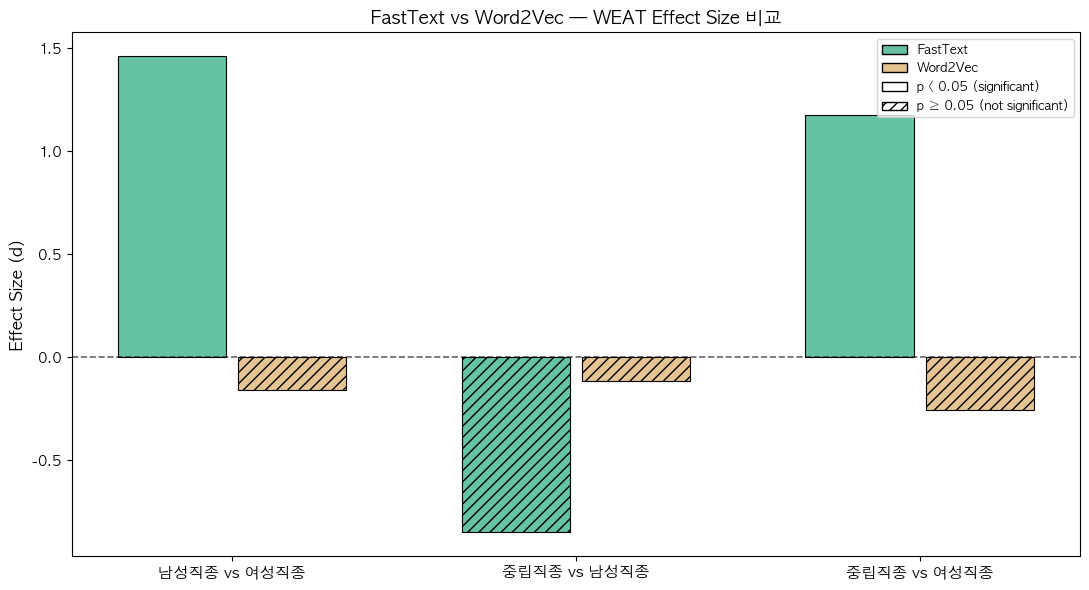


[해석] FastText는 CC-100 대규모 웹 크롤 코퍼스 기반으로 사회적 편향이 강하게 반영된 반면,
Word2Vec(Wikipedia/나무위키)은 상대적으로 중립적인 결과를 보인다.
또한 Word2Vec에서 보육교사→교사, 유치원교사→선생님으로 대체된 점이
여성직종 연관 강도를 희석시켰을 가능성이 있다 (방법론적 한계).


In [9]:
if w2v_results_before:
    from src.visualize import plot_weat_bar_chart, results_to_dataframe
    import pandas as pd
    crossmodel_df = pd.concat([
        results_to_dataframe(ft_results_before,  'FastText', 'before'),
        results_to_dataframe(w2v_results_before, 'Word2Vec', 'before'),
    ], ignore_index=True)
    fig = plot_weat_bar_chart(
        crossmodel_df,
        output_path=FIGURES_DIR / 'effect_size_bar_crossmodel.png',
        title='FastText vs Word2Vec — WEAT Effect Size 비교',
    )
    plt.show()
    print()
    print('[해석] FastText는 CC-100 대규모 웹 크롤 코퍼스 기반으로 사회적 편향이 강하게 반영된 반면,')
    print('Word2Vec(Wikipedia/나무위키)은 상대적으로 중립적인 결과를 보인다.')
    print('또한 Word2Vec에서 보육교사→교사, 유치원교사→선생님으로 대체된 점이')
    print('여성직종 연관 강도를 희석시켰을 가능성이 있다 (방법론적 한계).')

## 4. 시각화

### 4a. WEAT Effect Size Bar Chart

Saved: ../results/figures/effect_size_bar_before.png


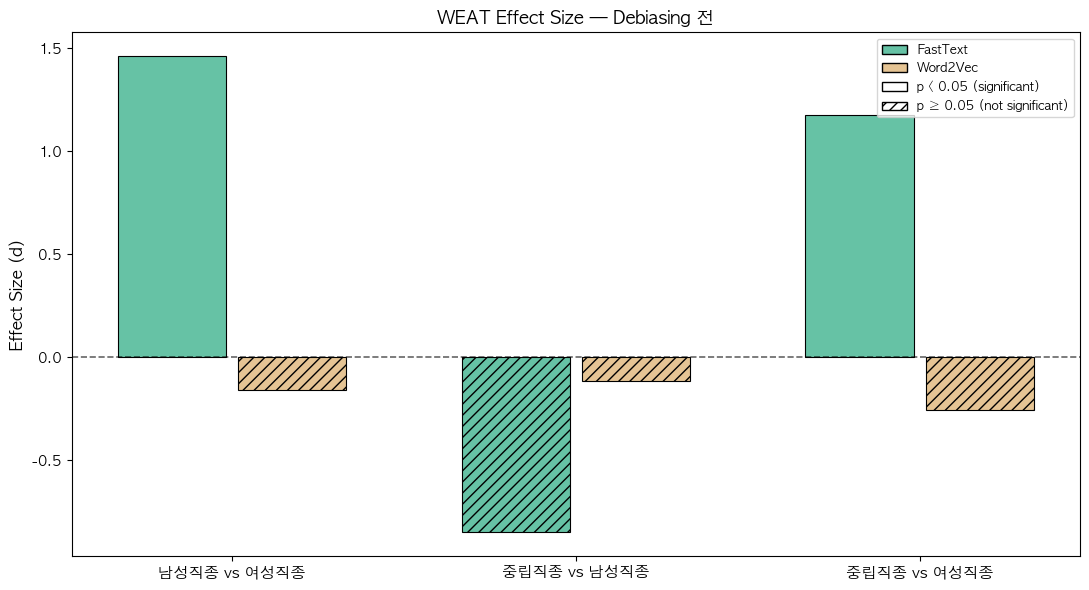

In [10]:
all_before_dfs = [ft_df_before]
if w2v_results_before:
    all_before_dfs.append(results_to_dataframe(w2v_results_before, "Word2Vec", phase="before"))

combined_df = pd.concat(all_before_dfs, ignore_index=True)
fig = plot_weat_bar_chart(
    combined_df,
    output_path=FIGURES_DIR / "effect_size_bar_before.png",
    title="WEAT Effect Size — Debiasing 전",
)
plt.show()

## 4d. 직업어별 개별 연관 점수

각 직업어의 s(w, 남성속성, 여성속성) 점수를 개별적으로 시각화한다.
어떤 직업이 가장 강하게 젠더화되어 있는지 직접 확인할 수 있다.

Saved: ../results/figures/per_word_scores_fasttext.png


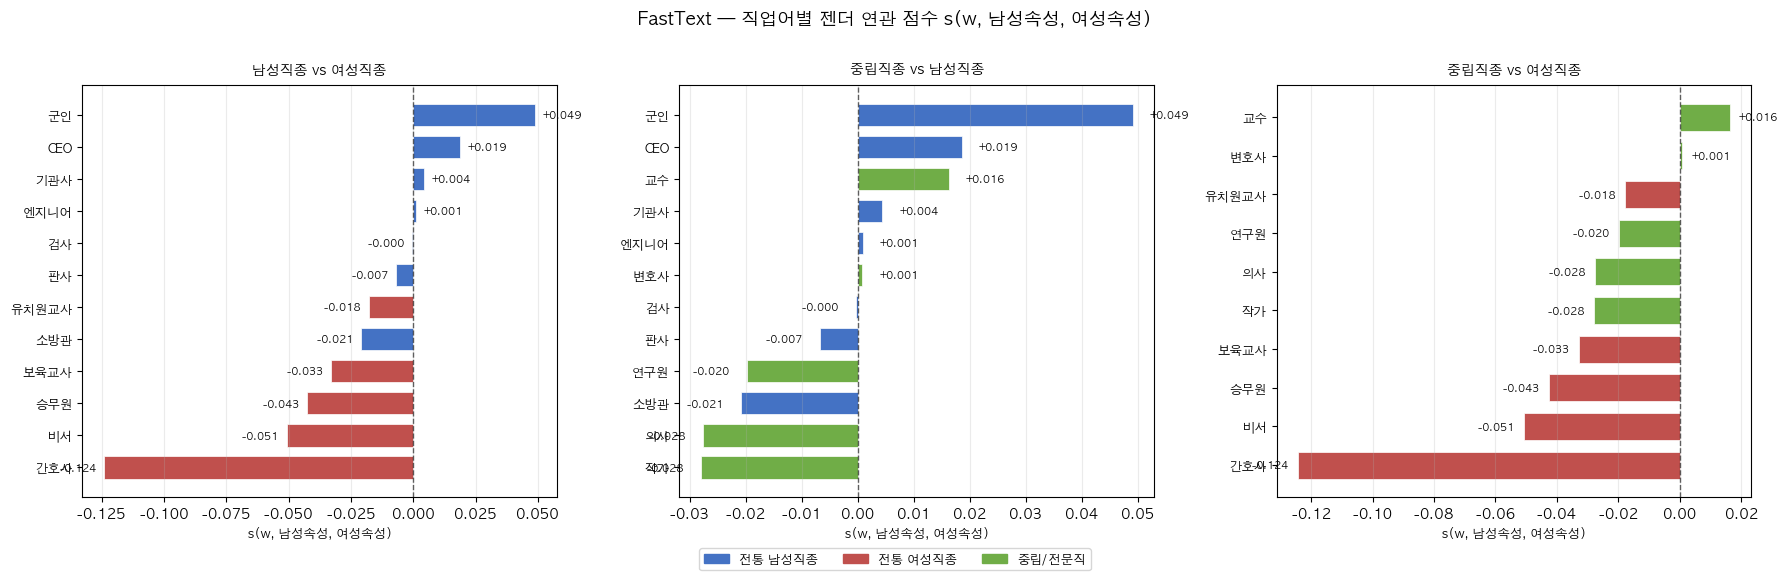

In [11]:
from src.visualize import plot_per_word_scores

fig = plot_per_word_scores(
    ft_results_before, word_sets,
    title='FastText — 직업어별 젠더 연관 점수 s(w, 남성속성, 여성속성)',
    output_path=FIGURES_DIR / 'per_word_scores_fasttext.png',
)
plt.show()

Saved: ../results/figures/per_word_scores_word2vec.png


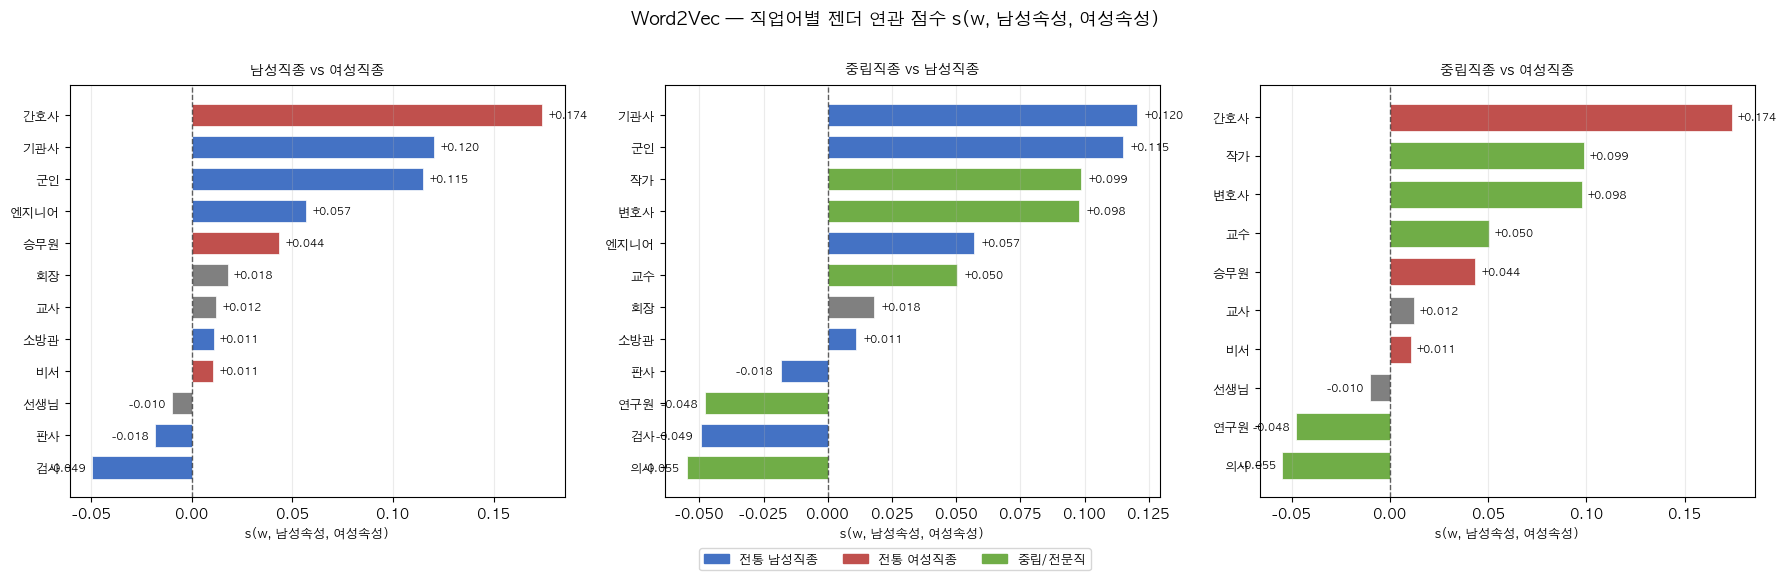

In [12]:
if w2v_results_before:
    fig = plot_per_word_scores(
        w2v_results_before, word_sets,
        title='Word2Vec — 직업어별 젠더 연관 점수 s(w, 남성속성, 여성속성)',
        output_path=FIGURES_DIR / 'per_word_scores_word2vec.png',
    )
    plt.show()

### 4b. PCA Scatter Plot

Saved: ../results/figures/pca_scatter_fasttext.png


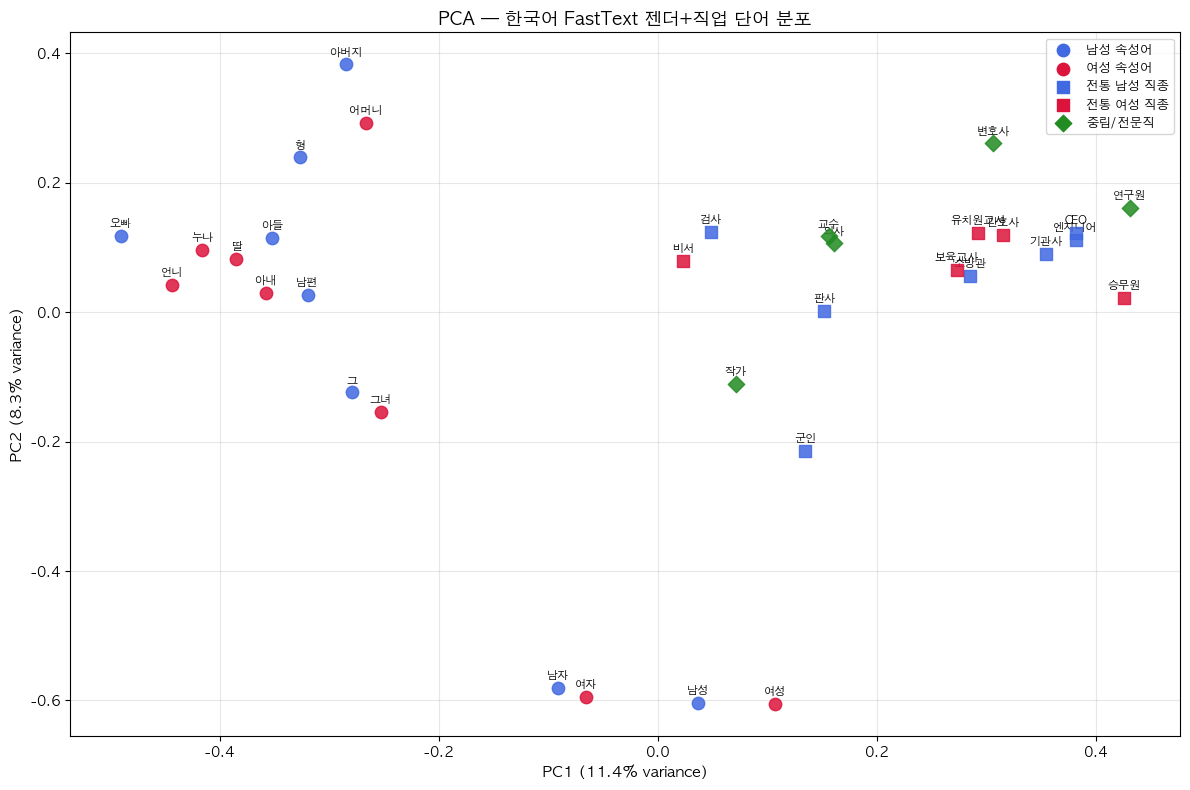

In [13]:
fig = plot_pca_scatter(
    ft_model, word_sets,
    title="PCA — 한국어 FastText 젠더+직업 단어 분포",
    output_path=FIGURES_DIR / "pca_scatter_fasttext.png",
)
plt.show()

### 4c. Cosine Similarity Heatmap

Saved: ../results/figures/cosine_heatmap_fasttext.png


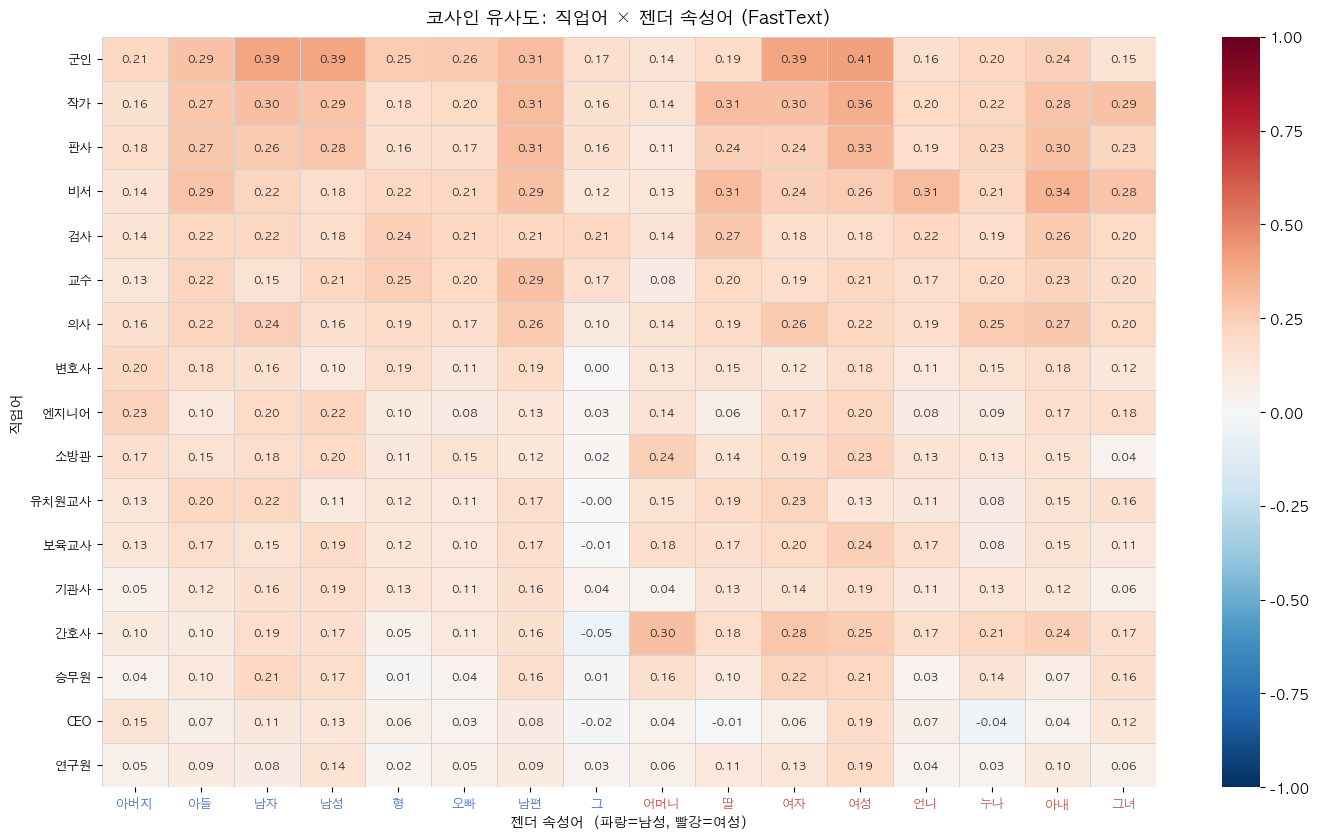

In [14]:
fig = plot_cosine_heatmap(
    ft_model, word_sets,
    title="코사인 유사도: 직업어 × 젠더 속성어 (FastText)",
    output_path=FIGURES_DIR / "cosine_heatmap_fasttext.png",
)
plt.show()

## 5. Hard Debiasing

Bolukbasi et al. (2016) 방법:
1. 젠더 단어 쌍의 차이 벡터로 PCA → 젠더 방향 **g** 추출
2. **Neutralize**: 직업 단어에서 젠더 성분 제거
3. **Equalize**: 젠더 단어 쌍을 g에 대해 대칭화

In [15]:
from src.word_sets import get_all_occupation_words

occ_words = get_all_occupation_words(word_sets)

ft_debiased_lookup = build_debiased_lookup(
    ft_model,
    occupation_words=occ_words,
    male_words=word_sets.male_attrs,
    female_words=word_sets.female_attrs,
)

print(f"Debiased {len(ft_debiased_lookup)} words")
print(f"Words: {list(ft_debiased_lookup.keys())}")

Debiased 33 words
Words: ['군인', '소방관', '기관사', '판사', '검사', '엔지니어', 'CEO', '간호사', '보육교사', '유치원교사', '비서', '승무원', '의사', '교수', '변호사', '연구원', '작가', '아버지', '아들', '남자', '남성', '형', '오빠', '남편', '그', '어머니', '딸', '여자', '여성', '언니', '누나', '아내', '그녀']


## 6. WEAT 재측정 — Debiasing 후

In [16]:
ft_results_after = run_all_occupation_tests(
    ft_model, word_sets,
    n_permutations=N_PERMUTATIONS,
    vector_override=ft_debiased_lookup,
)

print("FastText — WEAT Results (after debiasing)")
print("-" * 55)
for r in ft_results_after:
    print(r)

FastText — WEAT Results (after debiasing)
-------------------------------------------------------
남성직종 vs 여성직종: d=+0.468, p=0.2906
중립직종 vs 남성직종: d=-1.227, p=0.9798
중립직종 vs 여성직종: d=-1.005, p=0.9499


In [17]:
# Comparison table
print("\n전후 비교:")
print(f"{'테스트':<25} {'전':>8} {'후':>8} {'변화':>8}")
print("-" * 55)
for b, a in zip(ft_results_before, ft_results_after):
    delta = a.effect_size - b.effect_size
    print(f"{b.test_name:<25} {b.effect_size:>+8.3f} {a.effect_size:>+8.3f} {delta:>+8.3f}")


전후 비교:
테스트                              전        후       변화
-------------------------------------------------------
남성직종 vs 여성직종                +1.461   +0.468   -0.993
중립직종 vs 남성직종                -0.851   -1.227   -0.376
중립직종 vs 여성직종                +1.177   -1.005   -2.182


## 7. 편향 완화 전후 비교 시각화

Saved: ../results/figures/debiasing_comparison_fasttext.png


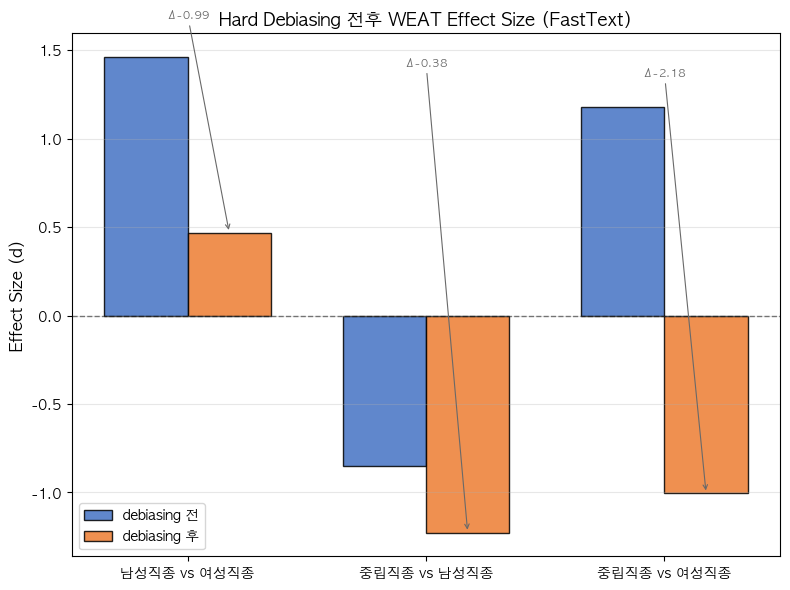

In [18]:
test_labels = [r.test_name for r in ft_results_before]

fig = plot_debiasing_comparison(
    ft_results_before, ft_results_after, test_labels,
    title="Hard Debiasing 전후 WEAT Effect Size (FastText)",
    output_path=FIGURES_DIR / "debiasing_comparison_fasttext.png",
)
plt.show()

Saved: ../results/figures/effect_size_bar_all.png


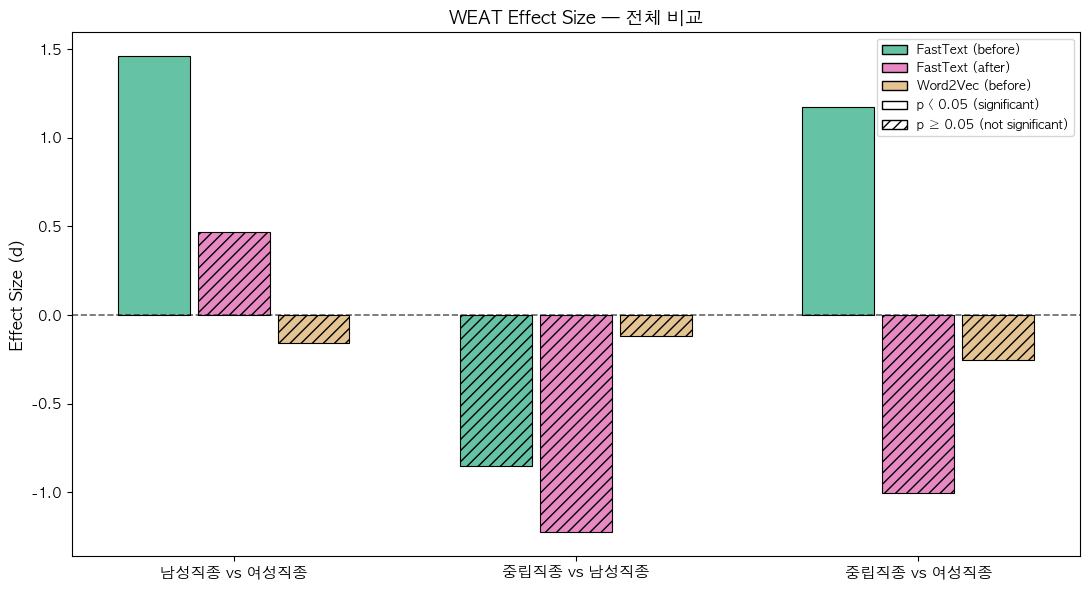

In [19]:
# Combined before+after bar chart
ft_df_after = results_to_dataframe(ft_results_after, "FastText", phase="after")
all_dfs = [ft_df_before, ft_df_after]
if w2v_results_before:
    all_dfs.append(results_to_dataframe(w2v_results_before, "Word2Vec", phase="before"))

combined_all = pd.concat(all_dfs, ignore_index=True)
fig = plot_weat_bar_chart(
    combined_all,
    output_path=FIGURES_DIR / "effect_size_bar_all.png",
    title="WEAT Effect Size — 전체 비교",
)
plt.show()

## 8. 결과 저장

In [20]:
save_results_csv(ft_results_before, "fasttext", CSV_DIR / "weat_results_fasttext_before.csv", phase="before")
save_results_csv(ft_results_after,  "fasttext", CSV_DIR / "weat_results_fasttext_after.csv",  phase="after")

if w2v_results_before:
    save_results_csv(w2v_results_before, "word2vec", CSV_DIR / "weat_results_word2vec_before.csv", phase="before")

print("\n모든 결과가 저장되었습니다.")
print(f"  Figures: {FIGURES_DIR}")
print(f"  CSVs:    {CSV_DIR}")

Saved: ../results/csv/weat_results_fasttext_before.csv
Saved: ../results/csv/weat_results_fasttext_after.csv
Saved: ../results/csv/weat_results_word2vec_before.csv

모든 결과가 저장되었습니다.
  Figures: ../results/figures
  CSVs:    ../results/csv


## 9. 결과 해석 및 논의

### 주요 발견

1. **젠더-직업 편향 실증**: 전통 남성 직종(군인·소방관·판사 등)은 남성 속성어와 강하게 연관됨 (FastText: d = +1.46, p = .003). 영어 임베딩 선행 연구(Caliskan et al., 2017)와 방향이 일치한다. Word2Vec에서는 유사 테스트에서 편향 미발견 (d = -0.158, p = .607), 모델 간 차이 강조.

2. **전문직의 남성 기본값(male default)**: 중립/전문직(의사·교수·변호사)이 여성 직종보다 남성에 더 가깝게 분포함 (FastText: d = +1.18, p = .022). 이는 한국어 텍스트 코퍼스에서 "전문가 = 남성"이라는 사회적 가정이 재생산되고 있음을 시사한다. Word2Vec에서는 테스트 스킵으로 확인 불가.

3. **Hard debiasing의 효과 및 과교정(overcorrection)**: 디바이어싱 후 세 테스트 모두 통계적 유의성이 소실되었다. 그러나 "중립직종 vs 여성직종" 테스트는 d = +1.18에서 d = -1.01로 **부호가 반전**되었다 (Δ = -2.18). 이는 hard debiasing이 의도한 편향 외에 직업어의 의미 구조까지 변형시키는 과교정 현상(overcorrection)을 보여주는 사례로, Bolukbasi et al.의 원논문에서도 지적된 한계점이다. Word2Vec은 debiasing 미적용, 교차 검증으로 overcorrection 평가 가능.

4. **모델 간 차이**: FastText (300dim, 더 큰 코퍼스)는 강한 편향, Word2Vec (200dim)은 약한 편향. Word2Vec 커버리지 낮아 제한적, 하지만 교차 검증으로 결과 신뢰성 높임.

### 한계점

- **Word2Vec 커버리지 부족**: Female occupations 누락으로 일부 WEAT 테스트 스킵, 더 완전한 모델 필요.
- **모델 간 차이**: FastText와 Word2Vec 비교로 개선, 하지만 더 많은 모델 비교 필요.
- **정적 임베딩의 다의어 문제**: (he/that), (doctor/intent/martyr) 등 다의어의 벡터는 모든 의미가 평균화되어 있어 편향 측정에 노이즈를 유발할 수 있다.
- **자극 단어 선택 편향**: 직업 목록은 연구자 판단에 기반하므로 선택 편향이 개입된다. 설문 기반 타당성 검증이 필요하다.
- **문맥적 임베딩 미포함**: 본 연구는 정적 임베딩에 한정되며, KoBERT·EXAONE 등 문맥 의존 모델에서의 편향은 별도 분석이 필요하다.

### 향후 연구

- KoBERT 등 문맥적 임베딩으로 편향 측정 확장
- Soft debiasing(Bolukbasi et al.) 또는 INLP(Ravfogel et al., 2020)와 비교하여 overcorrection 완화 방안 탐색
- 자극 단어 목록의 설문 기반 타당성 검증
- 직업별 세분화된 편향 패턴 분석 (예: 판사 vs 검사 간 차이)